# Fase 1 — Carregamento e Análise Exploratória de Imagens (EDA)

Nesta etapa será realizado o carregamento do dataset MNIST e uma análise inicial da estrutura dos dados.

Serão avaliados:
- dimensionalidade das matrizes X e y;
- distribuição das classes de 0 a 9;
- visualização de exemplos das imagens;
- representação das imagens 28 x 28 como 784 features;
- escala de intensidade dos pixels.


In [1]:
# Importação das bibliotecas necessárias.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca utilizada para medir o tempo de treinamento dos modelos.
import time

# Importa a função utilizada para carregar o dataset MNIST.
from sklearn.datasets import fetch_openml

# Importa a função utilizada para dividir os dados.
from sklearn.model_selection import train_test_split

# Importa o algoritmo KNN.
from sklearn.neighbors import KNeighborsClassifier

# Importa o algoritmo Random Forest para classificação.
from sklearn.ensemble import RandomForestClassifier

# Importa a rede neural Multilayer Perceptron para classificação.
from sklearn.neural_network import MLPClassifier

# Importa as métricas utilizadas na avaliação final dos modelos.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Importa Path, utilizado para criar e manipular caminhos de arquivos de forma organizada.
from pathlib import Path

# Importa Image para abrir e manipular imagens
# e ImageOps para aplicar operações como a inversão das cores.
from PIL import Image, ImageOps

In [2]:
# Carregar o dataset MNIST a partir do OpenML utilizando a função fetch_openml.

print("Baixando o dataset MNIST...")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto'
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.uint8)

print(f'Formato de X: {X.shape}')
print(f'Formato de y: {y.shape}')
print(f'Faixa original dos pixels: {X.min():.0f} a {X.max():.0f}')

print("Dataset MNIST baixado com sucesso!")

Baixando o dataset MNIST...
Formato de X: (70000, 784)
Formato de y: (70000,)
Faixa original dos pixels: 0 a 255
Dataset MNIST baixado com sucesso!


In [3]:
# Identifica as classes únicas em y e conta quantas vezes cada uma aparece.
classes, contagens = np.unique(y, return_counts=True)

# Organiza os resultados em um DataFrame do Pandas.
df_distribuicao = pd.DataFrame({
    'digito': classes,
    'quantidade': contagens
})

# Calcula o percentual de cada classe em relação ao total de imagens.
df_distribuicao['percentual'] = (
    df_distribuicao['quantidade'] / len(y) * 100
).round(2)

# Define a coluna "digito" como índice.
df_distribuicao = df_distribuicao.set_index('digito')

df_distribuicao

,quantidade,percentual
digito,,
0,6903,9.86
1,7877,11.25
2,6990,9.99
3,7141,10.20
4,6824,9.75
5,6313,9.02
6,6876,9.82
7,7293,10.42
8,6825,9.75


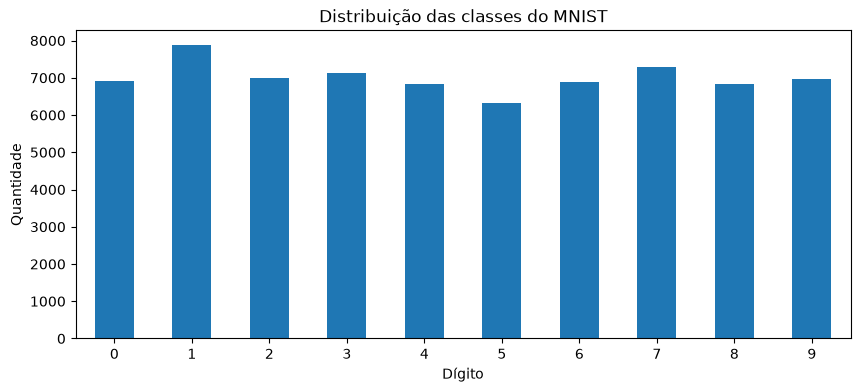

In [4]:
# Gera um gráfico de barras para facilitar a comparação visual das classes.
ax = df_distribuicao['quantidade'].plot.bar(figsize=(10, 4))

# Adiciona título e nomes aos eixos do gráfico.
ax.set(
    title='Distribuição das classes do MNIST',
    xlabel='Dígito',
    ylabel='Quantidade'
)

# Mantém os rótulos de 0 a 9 na horizontal.
ax.tick_params(axis='x', rotation=0)

# Exibe o gráfico.
plt.show()

### Análise da distribuição das classes

As quantidades de imagens entre os dígitos de 0 a 9 são relativamente próximas. Os percentuais ficam próximos de 10% por classe, indicando que o dataset MNIST apresenta uma distribuição relativamente balanceada entre as classes.

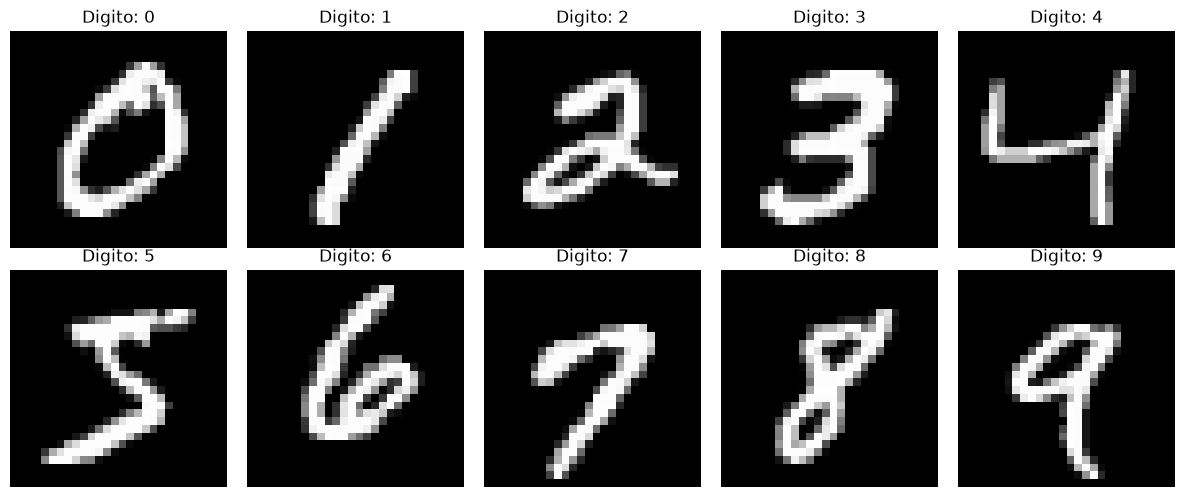

In [5]:
# Cria uma figura com 2 linhas e 5 colunas.
fig, axes = plt.subplots(2,5, figsize=(12,5))

# Percorre os dígitos de 0 a 9.

for digito in range(10):

     # Encontra a posição da primeira ocorrência desse dígito em y.
     indice = np.where(y == digito)[0][0]

     # Recupera a imagem correspondente e reorganiza para 28 x 28.
     imagem = X[indice].reshape(28, 28)

     # Define em qual posição da grade a imagem será exibida.
     eixo = axes.flat[digito]

     # Exibe a imagem em escala de cinza.
     eixo.imshow(imagem, cmap= 'gray')

     # Exibe o rótulo verdadeiro como título.
     eixo.set_title(f'Digito: {y[indice]}')

     # Remove os eixos para facilitar a visualização.
     eixo.axis('off')


# Ajusta o espaçamento entre as imagens.
plt.tight_layout()

# Exibe a grade completa.
plt.show()






### Interpretação da estrutura dos dados

O dataset MNIST possui 70.000 imagens de dígitos manuscritos. Cada imagem possui dimensão de 28 x 28 pixels, totalizando 784 pixels por imagem.

Para os modelos de Machine Learning, cada imagem é representada de forma vetorial, ou seja, os 784 pixels são organizados como 784 características (features) de entrada.

Os valores dos pixels variam de 0 a 255 e representam a intensidade de cada pixel na imagem em escala de cinza. Dessa forma, o modelo utiliza os valores numéricos dos pixels para aprender padrões que diferenciam os dígitos de 0 a 9.

# Fase 2 — Pipeline de Pré-processamento e Divisão dos Dados

Nesta etapa será realizado o pré-processamento dos dados do MNIST e a divisão do conjunto em subconjuntos de treino, validação e teste.

Serão avaliados:
- divisão dos dados em treino, validação e teste;
- uso de estratificação para preservar a proporção das classes;
- normalização dos valores dos pixels;
- verificação das dimensões dos subconjuntos gerados;
- justificativa da importância do pré-processamento para os modelos de Machine Learning.

In [6]:
# Importa a função utilizada para dividir os dados em subconjuntos.
from sklearn.model_selection import train_test_split

# Divide o conjunto completo em treino/validação e teste.
# 20% dos dados são reservados para o teste final.
X_treino_validacao, X_teste, y_treino_validacao, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [7]:
# Divide o conjunto de treino/validação em treino e validação.
# 12,5% dos 80% restantes correspondem a 10% do dataset original.
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_treino_validacao,
    y_treino_validacao,
    test_size=0.125,
    stratify=y_treino_validacao,
    random_state=42
)

In [8]:
# Cria uma tabela para conferir a quantidade e o percentual de dados em cada subconjunto.
df_divisao = pd.DataFrame({
    'conjunto': ['Treino', 'Validação', 'Teste'],
    'quantidade': [
        len(X_treino),
        len(X_validacao),
        len(X_teste)
    ]
})

# Calcula o percentual de cada conjunto em relação ao total.
df_divisao['percentual'] = (
    df_divisao['quantidade'] / len(X) *100
).round(2)

# Define a coluna "conjunto" como índice.
df_divisao = df_divisao.set_index('conjunto')

# Exibe a tabela.
df_divisao

,quantidade,percentual
conjunto,,
Treino,49000,70.0
Validação,7000,10.0
Teste,14000,20.0


In [9]:
# Normaliza os valores dos pixels para o intervalo entre 0.0 e 1.0.
X_treino = X_treino / 255.0
X_validacao = X_validacao /255.0
X_teste = X_teste / 255.0

In [10]:
# Cria uma tabela para verificar os valores mínimo e máximodos pixels após a normalização.

df_normalizacao = pd.DataFrame({
    'conjunto': ['Treino', 'Validação', 'Teste'],
    'valor_minimo': [
        X_treino.min(),
        X_validacao.min(),
        X_teste.min()
    ],
    'valor_maximo': [
        X_treino.max(),
        X_validacao.max(),
        X_teste.max()
    ]
})

# Define a coluna "conjunto" como índice.
df_normalizacao = df_normalizacao.set_index('conjunto')

# Exibe a tabela.
df_normalizacao

,valor_minimo,valor_maximo
conjunto,,
Treino,0.0,1.0
Validação,0.0,1.0
Teste,0.0,1.0


### Normalização dos dados

Os valores dos pixels originalmente variam entre 0 e 255. Nesta etapa, os dados foram normalizados para o intervalo entre 0.0 e 1.0 por meio da divisão dos valores por 255.0.

A normalização mantém a relação entre as intensidades dos pixels, mas reduz sua escala numérica. Esse pré-processamento é importante principalmente para modelos que utilizam cálculos de distância ou processos de otimização, pois facilita o tratamento dos valores durante o treinamento.

# Fase 3 — Implementação e Treinamento dos Modelos

Nesta etapa serão implementados e avaliados três modelos distintos de classificação para reconhecimento dos dígitos do dataset MNIST.

Os modelos escolhidos são:
- K-Nearest Neighbors (KNN);
- Random Forest;
- Multilayer Perceptron (MLP).

Para cada modelo serão avaliadas diferentes configurações de hiperparâmetros, buscando comparar seu comportamento e desempenho.

## 1. K-Nearest Neighbors (KNN)

O KNN classifica uma nova amostra com base nos exemplos mais próximos do conjunto de treino.

Para cada nova imagem, o algoritmo calcula quais amostras estão mais próximas e utiliza essas vizinhas para decidir qual dígito será previsto.

Neste projeto, serão avaliados dois hiperparâmetros principais:

- `n_neighbors`: define quantos vizinhos mais próximos serão considerados na decisão.
- `weights`: define como os vizinhos influenciam a classificação. Com `uniform`, todos possuem o mesmo peso; com `distance`, os vizinhos mais próximos possuem maior influência.

Serão comparadas diferentes combinações desses hiperparâmetros utilizando o conjunto de validação.

In [11]:
# Define as combinações de hiperparâmetros que serão avaliadas no KNN.
configuracoes_Knn = [
    {'n_neighbors': 3, 'weights': 'uniform'},
    {'n_neighbors': 3, 'weights': 'distance'},
    {'n_neighbors': 5, 'weights': 'uniform'},
    {'n_neighbors': 5, 'weights': 'distance'}   
]

In [12]:
# Lista que armazenará os resultados obtidos por cada configuração do KNN.
resultados_knn = []

# Percorre cada combinação de hiperparâmetros definida anteriormente.
for configuracao in configuracoes_Knn:

    # Cria o modelo KNN com a configuração atual.
    modelo_knn = KNeighborsClassifier(
        n_neighbors=configuracao['n_neighbors'],
        weights=configuracao['weights']
    )

    # Mede o tempo de treinamento.
    inicio_treino = time.perf_counter()

    modelo_knn.fit(X_treino, y_treino)

    tempo_treino = time.perf_counter() - inicio_treino

    # Mede o tempo necessário para realizar as previsões.
    inicio_predicao = time.perf_counter()

    y_pred_validacao = modelo_knn.predict(X_validacao)

    tempo_predicao = time.perf_counter() - inicio_predicao

    # Calcula a acurácia no conjunto de validação.
    acuracia_validacao = accuracy_score(
        y_validacao,
        y_pred_validacao
    )

    # Armazena os resultados.
    resultados_knn.append({
        'n_neighbors': configuracao['n_neighbors'],
        'weights': configuracao['weights'],
        'acuracia_validacao': acuracia_validacao,
        'tempo_treino_segundos': tempo_treino,
        'tempo_predicao_segundos': tempo_predicao
    })

In [13]:
# Organiza os resultados das configurações em um DataFrame.
df_resultados_knn = pd.DataFrame(resultados_knn)

# Converte a acurácia para percentual.
df_resultados_knn['acuracia_validacao'] = (
    df_resultados_knn['acuracia_validacao'] * 100
).round(2)

# Arredonda o tempo de treinamento.
df_resultados_knn['tempo_treino_segundos'] = (
    df_resultados_knn['tempo_treino_segundos']
).round(4)

# Arredonda o tempo de predição.
df_resultados_knn['tempo_predicao_segundos'] = (
    df_resultados_knn['tempo_predicao_segundos']
).round(4)

# Ordena as configurações da maior para a menor acurácia.
df_resultados_knn = df_resultados_knn.sort_values(
    by='acuracia_validacao',
    ascending=False
).reset_index(drop=True)

# Exibe os resultados.
df_resultados_knn

,n_neighbors,weights,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
0,3,distance,97.23,0.0124,3.7304
1,3,uniform,97.19,0.0166,3.5541
2,5,distance,97.14,0.0120,3.4392
3,5,uniform,96.94,0.0139,3.5916


In [14]:
# Seleciona a configuração que apresentou a maior acurácia na validação.
melhor_configuracao_knn = df_resultados_knn.iloc[0]

# Organiza a melhor configuração em formato de DataFrame.
df_melhor_knn = pd.DataFrame({
    'modelo': ['KNN'],
    'n_neighbors': [melhor_configuracao_knn['n_neighbors']],
    'weights': [melhor_configuracao_knn['weights']],
    'acuracia_validacao': [melhor_configuracao_knn['acuracia_validacao']],
    'tempo_treino_segundos': [melhor_configuracao_knn['tempo_treino_segundos']],
    'tempo_predicao_segundos': [melhor_configuracao_knn['tempo_predicao_segundos']]
})

# Define a coluna "modelo" como índice.
df_melhor_knn = df_melhor_knn.set_index('modelo')

# Exibe a melhor configuração.
df_melhor_knn

,n_neighbors,weights,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
modelo,,,,,
KNN,3,distance,97.23,0.0124,3.7304


### Análise do KNN

As diferentes configurações do KNN apresentaram resultados próximos no conjunto de validação.

A melhor configuração foi obtida com `n_neighbors = 3` e `weights = 'distance'`, alcançando acurácia de validação de **97,23%**.

Nos testes realizados, o uso de `weights = 'distance'` apresentou desempenho ligeiramente superior ao `weights = 'uniform'` para os valores de K avaliados. Além disso, `n_neighbors = 3` apresentou resultados um pouco melhores que `n_neighbors = 5`.

A diferença entre as configurações foi pequena, indicando que o modelo apresentou desempenho consistente entre os hiperparâmetros testados.

A configuração com `n_neighbors = 3` e `weights = 'distance'` será utilizada como melhor configuração do KNN para as próximas etapas de avaliação.

## 2. Random Forest

O Random Forest é um algoritmo de classificação baseado na combinação de várias árvores de decisão.

Cada árvore realiza suas próprias decisões a partir dos dados e, ao final, o Random Forest combina os resultados dessas árvores para definir a classe prevista.

Neste projeto serão avaliados dois hiperparâmetros:

- `n_estimators`: define a quantidade de árvores utilizadas pelo modelo.
- `max_depth`: define a profundidade máxima que cada árvore pode atingir.

Uma quantidade maior de árvores pode tornar as previsões mais estáveis, mas também pode aumentar o custo computacional. Já `max_depth` controla a complexidade das árvores e pode ajudar a reduzir o risco de overfitting.

As diferentes configurações serão comparadas utilizando o conjunto de validação.

In [15]:
# Define as combinações de hiperparâmetros que serão avaliadas no Random Forest.

configuracoes_rf = [
    {'n_estimators': 50, 'max_depth': 10},
    {'n_estimators': 50, 'max_depth': None},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': None}
]

In [16]:
# Lista que armazenará os resultados obtidos por cada configuração do Random Forest.
resultados_rf = []

# Percorre cada combinação de hiperparâmetros definida anteriormente.
for configuracao in configuracoes_rf:

    # Cria o modelo Random Forest com a configuração atual.
    modelo_rf = RandomForestClassifier(
        n_estimators=configuracao['n_estimators'],
        max_depth=configuracao['max_depth'],
        random_state=42,
        n_jobs=-1
    )

    # Mede o tempo de treinamento.
    inicio_treino = time.perf_counter()

    # Treina o modelo utilizando o conjunto de treino.
    modelo_rf.fit(X_treino, y_treino)

    # Calcula o tempo utilizado no treinamento.
    tempo_treino = time.perf_counter() - inicio_treino

    # Mede o tempo necessário para realizar as previsões.
    inicio_predicao = time.perf_counter()

    # Realiza previsões utilizando o conjunto de validação.
    y_pred_validacao = modelo_rf.predict(X_validacao)

    # Calcula o tempo utilizado na predição.
    tempo_predicao = time.perf_counter() - inicio_predicao

    # Calcula a acurácia obtida no conjunto de validação.
    acuracia_validacao = accuracy_score(
        y_validacao,
        y_pred_validacao
    )

    # Armazena os hiperparâmetros e os resultados obtidos.
    resultados_rf.append({
        'n_estimators': configuracao['n_estimators'],
        'max_depth': configuracao['max_depth'],
        'acuracia_validacao': acuracia_validacao,
        'tempo_treino_segundos': tempo_treino,
        'tempo_predicao_segundos': tempo_predicao
    })

In [17]:
# Organiza os resultados das configurações em um DataFrame.
df_resultados_rf = pd.DataFrame(resultados_rf)

# Converte a acurácia para percentual.
df_resultados_rf['acuracia_validacao'] = (
    df_resultados_rf['acuracia_validacao'] * 100
).round(2)

# Arredonda o tempo de treinamento.
df_resultados_rf['tempo_treino_segundos'] = (
    df_resultados_rf['tempo_treino_segundos']
).round(4)

# Arredonda o tempo de predição.
df_resultados_rf['tempo_predicao_segundos'] = (
    df_resultados_rf['tempo_predicao_segundos']
).round(4)

# Ordena as configurações da maior para a menor acurácia.
df_resultados_rf = df_resultados_rf.sort_values(
    by='acuracia_validacao',
    ascending=False
).reset_index(drop=True)

# Exibe os resultados.
df_resultados_rf

,n_estimators,max_depth,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
0,100,NaN,96.61,5.3185,0.0583
1,50,NaN,96.50,2.8017,0.0373
2,100,10.0,94.64,4.0283,0.0473
3,50,10.0,94.46,1.9576,0.0385


In [18]:
# Seleciona a configuração que apresentou a maior acurácia na validação.
melhor_configuracao_rf = df_resultados_rf.iloc[0]

# Organiza a melhor configuração em formato de DataFrame.
df_melhor_rf = pd.DataFrame({
    'modelo': ['Random Forest'],
    'n_estimators': [melhor_configuracao_rf['n_estimators']],
    'max_depth': [melhor_configuracao_rf['max_depth']],
    'acuracia_validacao': [melhor_configuracao_rf['acuracia_validacao']],
    'tempo_treino_segundos': [melhor_configuracao_rf['tempo_treino_segundos']],
    'tempo_predicao_segundos': [melhor_configuracao_rf['tempo_predicao_segundos']]
})

# Define a coluna "modelo" como índice.
df_melhor_rf = df_melhor_rf.set_index('modelo')

# Exibe a melhor configuração.
df_melhor_rf

,n_estimators,max_depth,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
modelo,,,,,
Random Forest,100.0,NaN,96.61,5.3185,0.0583


### Análise do Random Forest

As diferentes configurações do Random Forest apresentaram diferenças relevantes de desempenho no conjunto de validação.

A melhor configuração utilizou `n_estimators = 100` e `max_depth = None`, alcançando acurácia de validação de **96,61%**.

Nos experimentos realizados, as configurações sem limite explícito de profundidade apresentaram resultados superiores às configurações com `max_depth = 10`. Isso indica que limitar as árvores a essa profundidade reduziu a capacidade do modelo de representar os padrões presentes nos dados.

O aumento de 50 para 100 árvores gerou uma pequena melhora na acurácia, porém também aumentou o tempo de treinamento. Dessa forma, a configuração com 100 árvores apresentou o melhor desempenho, mas com maior custo computacional.

A configuração com `n_estimators = 100` e `max_depth = None` será utilizada como melhor configuração do Random Forest nas próximas etapas de avaliação.

## 3. Multilayer Perceptron (MLP)

O Multilayer Perceptron (MLP) é uma rede neural artificial composta por uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída.

No MNIST, os 784 valores dos pixels são utilizados como entradas da rede. Durante o treinamento, o modelo ajusta pesos internos para aprender padrões que ajudam a diferenciar os dígitos de 0 a 9.

Neste projeto serão avaliados dois hiperparâmetros principais:

- `hidden_layer_sizes`: define a quantidade de neurônios e a estrutura das camadas ocultas.
- `alpha`: controla a regularização do modelo, ajudando a reduzir o risco de overfitting.

As diferentes configurações serão comparadas utilizando o conjunto de validação.

In [19]:
# Define as combinações de hiperparâmetros que serão avaliadas no MLP.

configuracoes_mlp = [
    {'hidden_layer_sizes': (64,), 'alpha': 0.0001},
    {'hidden_layer_sizes': (64,), 'alpha': 0.001},
    {'hidden_layer_sizes': (128,), 'alpha': 0.0001},
    {'hidden_layer_sizes': (128,), 'alpha': 0.001}
]

In [20]:
# Lista que armazenará os resultados obtidos por cada configuração do MLP.
resultados_mlp = []

# Percorre cada combinação de hiperparâmetros definida anteriormente.
for configuracao in configuracoes_mlp:

    # Cria o modelo MLP com a configuração atual.
    modelo_mlp = MLPClassifier(
        hidden_layer_sizes=configuracao['hidden_layer_sizes'],
        alpha=configuracao['alpha'],
        max_iter=20,
        random_state=42
    )

    # Mede o tempo de treinamento.
    inicio_treino = time.perf_counter()

    # Treina o modelo utilizando o conjunto de treino.
    modelo_mlp.fit(X_treino, y_treino)

    # Calcula o tempo utilizado no treinamento.
    tempo_treino = time.perf_counter() - inicio_treino

    # Mede o tempo necessário para realizar as previsões.
    inicio_predicao = time.perf_counter()

    # Realiza previsões utilizando o conjunto de validação.
    y_pred_validacao = modelo_mlp.predict(X_validacao)

    # Calcula o tempo utilizado na predição.
    tempo_predicao = time.perf_counter() - inicio_predicao

    # Calcula a acurácia obtida no conjunto de validação.
    acuracia_validacao = accuracy_score(
        y_validacao,
        y_pred_validacao
    )

    # Armazena os hiperparâmetros e os resultados obtidos.
    resultados_mlp.append({
        'hidden_layer_sizes': configuracao['hidden_layer_sizes'],
        'alpha': configuracao['alpha'],
        'acuracia_validacao': acuracia_validacao,
        'tempo_treino_segundos': tempo_treino,
        'tempo_predicao_segundos': tempo_predicao
    })

/home/thiago/Documentos/projeto-modulo-2-SCTEC/mini-projeto-mnist-sctec/projeto-mnist/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/thiago/Documentos/projeto-modulo-2-SCTEC/mini-projeto-mnist-sctec/projeto-mnist/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/thiago/Documentos/projeto-modulo-2-SCTEC/mini-projeto-mnist-sctec/projeto-mnist/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/thiago/Documentos/projeto-modulo-2-SCTEC/mini-projeto-mnist-sctec/p

In [21]:
# Organiza os resultados das configurações em um DataFrame.
df_resultados_mlp = pd.DataFrame(resultados_mlp)

# Converte a acurácia para percentual.
df_resultados_mlp['acuracia_validacao'] = (
    df_resultados_mlp['acuracia_validacao'] * 100
).round(2)

# Arredonda o tempo de treinamento.
df_resultados_mlp['tempo_treino_segundos'] = (
    df_resultados_mlp['tempo_treino_segundos']
).round(4)

# Arredonda o tempo de predição.
df_resultados_mlp['tempo_predicao_segundos'] = (
    df_resultados_mlp['tempo_predicao_segundos']
).round(4)

# Ordena as configurações da maior para a menor acurácia.
df_resultados_mlp = df_resultados_mlp.sort_values(
    by='acuracia_validacao',
    ascending=False
).reset_index(drop=True)

# Exibe os resultados.
df_resultados_mlp

,hidden_layer_sizes,alpha,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
0,"(128,)",0.0010,97.41,9.2169,0.0152
1,"(128,)",0.0001,97.39,10.7724,0.0143
2,"(64,)",0.0001,97.06,9.5504,0.0109
3,"(64,)",0.0010,97.01,9.5631,0.0120


In [22]:
# Seleciona a configuração que apresentou a maior acurácia na validação.
melhor_configuracao_mlp = df_resultados_mlp.iloc[0]

# Organiza a melhor configuração em formato de DataFrame.
df_melhor_mlp = pd.DataFrame({
    'modelo': ['MLP'],
    'hidden_layer_sizes': [melhor_configuracao_mlp['hidden_layer_sizes']],
    'alpha': [melhor_configuracao_mlp['alpha']],
    'acuracia_validacao': [melhor_configuracao_mlp['acuracia_validacao']],
    'tempo_treino_segundos': [melhor_configuracao_mlp['tempo_treino_segundos']],
    'tempo_predicao_segundos': [melhor_configuracao_mlp['tempo_predicao_segundos']]
})

# Define a coluna "modelo" como índice.
df_melhor_mlp = df_melhor_mlp.set_index('modelo')

# Exibe a melhor configuração.
df_melhor_mlp

,hidden_layer_sizes,alpha,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
modelo,,,,,
MLP,"(128,)",0.001,97.41,9.2169,0.0152


### Análise do MLP

As diferentes configurações do MLP apresentaram bons resultados no conjunto de validação.

A melhor configuração utilizou uma camada oculta com 128 neurônios (`hidden_layer_sizes = (128,)`) e `alpha = 0.001`, alcançando acurácia de validação de **97,41%**.

Nos experimentos realizados, as configurações com 128 neurônios apresentaram desempenho superior às configurações com 64 neurônios. A diferença entre os valores de regularização (`alpha`) foi pequena, indicando que, entre os valores testados, a quantidade de neurônios teve maior impacto na acurácia.

A configuração com 128 neurônios também apresentou maior tempo de treinamento, mostrando uma relação entre aumento da capacidade do modelo e maior custo computacional.

Durante alguns treinamentos, o modelo atingiu o limite definido de 20 iterações antes da convergência completa. Esse limite foi mantido para controlar o custo computacional do experimento.

A configuração com `hidden_layer_sizes = (128,)` e `alpha = 0.001` será utilizada como melhor configuração do MLP nas próximas etapas de avaliação.

# Fase 4 — Avaliação Comparativa de Desempenho

Nesta etapa, as melhores configurações encontradas para KNN, Random Forest e MLP serão avaliadas utilizando o conjunto de teste independente.

Para cada modelo serão analisadas:

- Acurácia global (Accuracy);
- Precisão média ponderada (Precision);
- Revocação média ponderada (Recall);
- F1-Score ponderado;
- Matriz de confusão 10 x 10;
- Tempo de treinamento e predição.

O conjunto de teste será utilizado somente nesta avaliação final, após a escolha dos hiperparâmetros realizada com o conjunto de validação.

## Avaliação dos melhores modelos no conjunto de teste

A partir dos resultados obtidos no conjunto de validação, foram selecionadas as seguintes configurações:

- **KNN:** `n_neighbors = 3` e `weights = 'distance'`;
- **Random Forest:** `n_estimators = 100` e `max_depth = None`;
- **MLP:** `hidden_layer_sizes = (128,)` e `alpha = 0.001`.

Essas configurações serão novamente treinadas utilizando o conjunto de treino e avaliadas no conjunto de teste, que permaneceu separado durante a escolha dos hiperparâmetros.

In [23]:
# Cria os modelos finais utilizando as melhores configurações encontradas durante a etapa de validação.

modelo_final_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

modelo_final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

modelo_final_mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    alpha=0.001,
    max_iter=20,
    random_state=42
)

In [24]:
# Função responsável por treinar e avaliar um modelo no conjunto de teste.

def avaliar_modelo(nome_modelo, modelo, X_treino, y_treino, X_teste, y_teste):

    # Mede o tempo de treinamento.
    inicio_treino = time.perf_counter()

    modelo.fit(X_treino, y_treino)

    tempo_treino = time.perf_counter() - inicio_treino

    # Mede o tempo de predição.
    inicio_predicao = time.perf_counter()

    y_pred = modelo.predict(X_teste)

    tempo_predicao = time.perf_counter() - inicio_predicao

    # Calcula as métricas de avaliação.
    acuracia = accuracy_score(y_teste, y_pred)

    precisao = precision_score(
        y_teste,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_teste,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_teste,
        y_pred,
        average='weighted'
    )

    # Calcula a matriz de confusão.
    matriz_confusao = confusion_matrix(
        y_teste,
        y_pred
    )

    # Retorna todos os resultados.
    return {
        'modelo': nome_modelo,
        'acuracia': acuracia,
        'precisao': precisao,
        'recall': recall,
        'f1_score': f1,
        'tempo_treino_segundos': tempo_treino,
        'tempo_predicao_segundos': tempo_predicao,
        'y_pred': y_pred,
        'matriz_confusao': matriz_confusao
    }

In [25]:
# Avalia cada modelo utilizando o conjunto de teste.

resultado_final_knn = avaliar_modelo(
    'KNN',
    modelo_final_knn,
    X_treino,
    y_treino,
    X_teste,
    y_teste
)

resultado_final_rf = avaliar_modelo(
    'Random Forest',
    modelo_final_rf,
    X_treino,
    y_treino,
    X_teste,
    y_teste
)

resultado_final_mlp = avaliar_modelo(
    'MLP',
    modelo_final_mlp,
    X_treino,
    y_treino,
    X_teste,
    y_teste
)

/home/thiago/Documentos/projeto-modulo-2-SCTEC/mini-projeto-mnist-sctec/projeto-mnist/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [26]:
# Organiza as métricas dos três modelos em uma tabela comparativa.

df_comparacao_final = pd.DataFrame([
    {
        'modelo': resultado_final_knn['modelo'],
        'acuracia': resultado_final_knn['acuracia'],
        'precisao': resultado_final_knn['precisao'],
        'recall': resultado_final_knn['recall'],
        'f1_score': resultado_final_knn['f1_score'],
        'tempo_treino_segundos': resultado_final_knn['tempo_treino_segundos'],
        'tempo_predicao_segundos': resultado_final_knn['tempo_predicao_segundos']
    },
    {
        'modelo': resultado_final_rf['modelo'],
        'acuracia': resultado_final_rf['acuracia'],
        'precisao': resultado_final_rf['precisao'],
        'recall': resultado_final_rf['recall'],
        'f1_score': resultado_final_rf['f1_score'],
        'tempo_treino_segundos': resultado_final_rf['tempo_treino_segundos'],
        'tempo_predicao_segundos': resultado_final_rf['tempo_predicao_segundos']
    },
    {
        'modelo': resultado_final_mlp['modelo'],
        'acuracia': resultado_final_mlp['acuracia'],
        'precisao': resultado_final_mlp['precisao'],
        'recall': resultado_final_mlp['recall'],
        'f1_score': resultado_final_mlp['f1_score'],
        'tempo_treino_segundos': resultado_final_mlp['tempo_treino_segundos'],
        'tempo_predicao_segundos': resultado_final_mlp['tempo_predicao_segundos']
    }
])

# Converte as métricas para percentual.
colunas_metricas = [
    'acuracia',
    'precisao',
    'recall',
    'f1_score'
]

df_comparacao_final[colunas_metricas] = (
    df_comparacao_final[colunas_metricas] * 100
).round(2)

# Arredonda os tempos.
df_comparacao_final['tempo_treino_segundos'] = (
    df_comparacao_final['tempo_treino_segundos']
).round(4)

df_comparacao_final['tempo_predicao_segundos'] = (
    df_comparacao_final['tempo_predicao_segundos']
).round(4)

# Ordena da maior para a menor acurácia.
df_comparacao_final = df_comparacao_final.sort_values(
    by='acuracia',
    ascending=False
).reset_index(drop=True)

# Define o nome do modelo como índice.
df_comparacao_final = df_comparacao_final.set_index('modelo')

df_comparacao_final

,acuracia,precisao,recall,f1_score,tempo_treino_segundos,tempo_predicao_segundos
modelo,,,,,,
MLP,97.76,97.76,97.76,97.76,8.7693,0.0286
KNN,97.21,97.24,97.21,97.21,0.0147,7.0512
Random Forest,96.51,96.51,96.51,96.51,4.9315,0.1389


## Matrizes de Confusão

As matrizes de confusão permitem analisar com maior detalhe os acertos e erros de cada modelo.

Nas matrizes, as linhas representam as classes verdadeiras e as colunas representam as classes previstas pelo modelo.

Os valores presentes na diagonal principal correspondem às classificações corretas, enquanto os valores fora da diagonal indicam quais dígitos foram confundidos pelo modelo.

In [27]:
# Função utilizada para exibir a matriz de confusão de cada modelo.

def plotar_matriz_confusao(matriz, nome_modelo):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        matriz,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False
    )

    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.xlabel('Classe prevista')
    plt.ylabel('Classe verdadeira')

    plt.show()

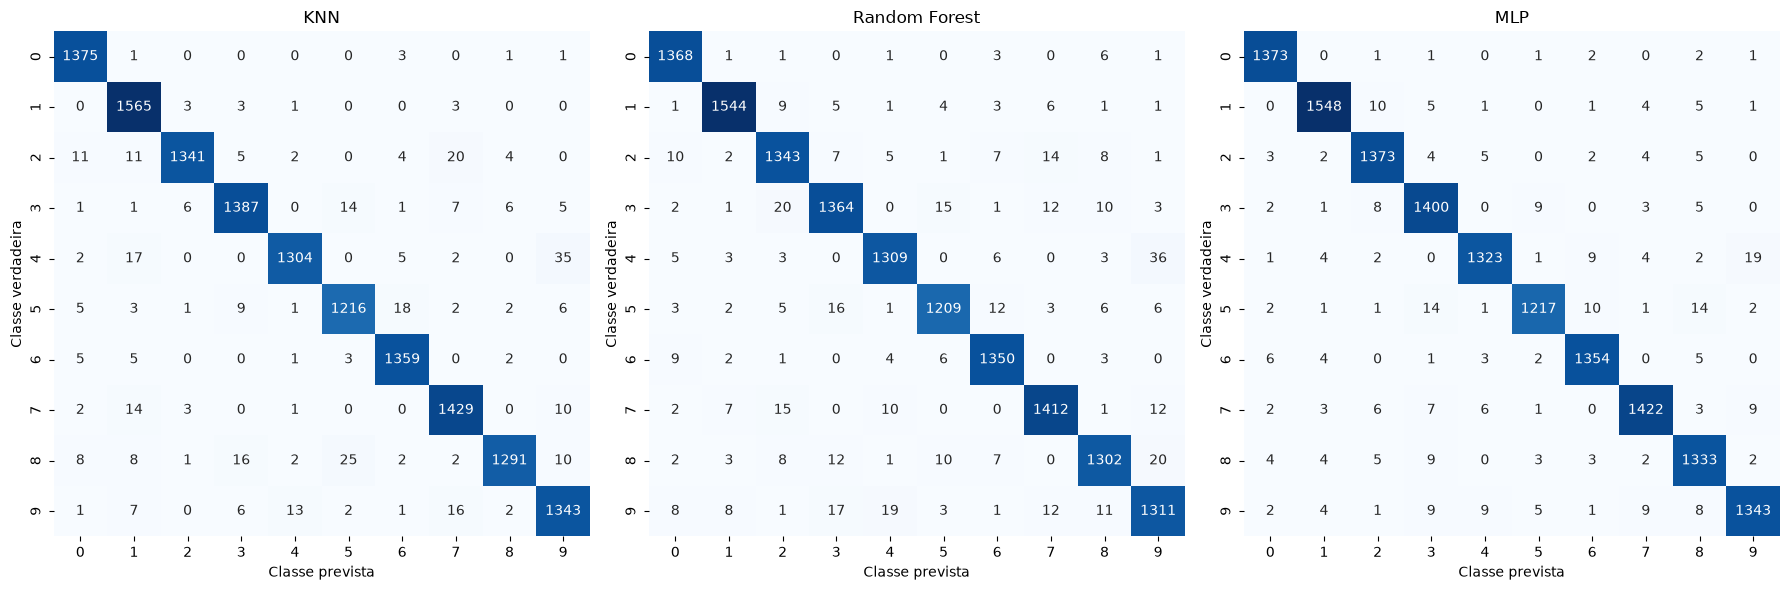

In [28]:
# Exibe as matrizes de confusão dos três modelos lado a lado.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Matriz de confusão do KNN
sns.heatmap(
    resultado_final_knn['matriz_confusao'],
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0]
)
axes[0].set_title('KNN')
axes[0].set_xlabel('Classe prevista')
axes[0].set_ylabel('Classe verdadeira')

# Matriz de confusão do Random Forest
sns.heatmap(
    resultado_final_rf['matriz_confusao'],
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[1]
)
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Classe prevista')
axes[1].set_ylabel('Classe verdadeira')

# Matriz de confusão do MLP
sns.heatmap(
    resultado_final_mlp['matriz_confusao'],
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[2]
)
axes[2].set_title('MLP')
axes[2].set_xlabel('Classe prevista')
axes[2].set_ylabel('Classe verdadeira')

plt.tight_layout()
plt.show()

### Análise das matrizes de confusão

As três matrizes de confusão apresentam forte concentração de valores na diagonal principal, indicando que os modelos classificaram corretamente a maior parte das imagens do conjunto de teste.

O **MLP apresentou o melhor desempenho geral**, com acurácia, precisão, recall e F1-score de aproximadamente **97,76%**, além de apresentar menos erros fora da diagonal quando comparado aos demais modelos.

O **KNN** também apresentou bom desempenho, alcançando **97,21% de acurácia**. Entre suas maiores confusões, destacam-se imagens do dígito **4 classificadas como 9**, com 35 ocorrências, além de casos do dígito **8 classificados como 5** e do dígito **2 classificados como 7**.

O **Random Forest** apresentou acurácia de **96,51%**, sendo o modelo com menor desempenho entre os três avaliados. Sua maior confusão também ocorreu entre os dígitos **4 e 9**, com 36 imagens do dígito 4 classificadas como 9. Também foram observadas confusões entre os dígitos **3 e 2** e entre **9 e 4**.

No **MLP**, a maior confusão também ocorreu entre os dígitos **4 e 9**, porém em menor quantidade, com 19 casos. Outras confusões relevantes ocorreram entre o dígito **5 e os dígitos 3 e 8**.

De forma geral, os resultados mostram que alguns dígitos com formatos visuais semelhantes podem ser confundidos pelos modelos. Entre os três modelos avaliados, o MLP apresentou o melhor equilíbrio entre as métricas e a menor quantidade de erros de classificação.

In [29]:
# Função para identificar as maiores taxas de confusão de cada modelo.

def identificar_maiores_confusoes(matriz, nome_modelo, quantidade=5):

    # Lista que armazenará os erros e suas taxas.
    confusoes = []

    # Percorre cada classe verdadeira (cada linha da matriz).
    for classe_real in range(matriz.shape[0]):

        # Soma todos os exemplos dessa classe, incluindo acertos e erros.
        total_classe_real = matriz[classe_real].sum()

        # Percorre as classes previstas (colunas da matriz).
        for classe_prevista in range(matriz.shape[1]):

            # Ignora a diagonal, pois ela representa os acertos.
            if classe_real == classe_prevista:
                continue

            # Obtém a quantidade de erros para esse par de classes.
            quantidade_erros = matriz[classe_real, classe_prevista]

            # Registra apenas os pares em que ocorreram erros.
            if quantidade_erros > 0:

                # Calcula o percentual de exemplos da classe verdadeira
                # que foram confundidos com a classe prevista.
                taxa_confusao = (
                    quantidade_erros / total_classe_real
                ) * 100

                # Guarda os resultados desse par de classes.
                confusoes.append({
                    'modelo': nome_modelo,
                    'classe_real': classe_real,
                    'classe_prevista': classe_prevista,
                    'quantidade_erros': quantidade_erros,
                    'total_classe_real': total_classe_real,
                    'taxa_confusao_percentual': taxa_confusao
                })

    # Transforma a lista de resultados em uma tabela.
    df_confusoes = pd.DataFrame(confusoes)

    # Ordena pela maior taxa e seleciona os primeiros resultados.
    df_confusoes = df_confusoes.sort_values(
        by='taxa_confusao_percentual',
        ascending=False
    ).head(quantidade)

    # Arredonda o percentual apenas depois de ordenar.
    df_confusoes['taxa_confusao_percentual'] = (
        df_confusoes['taxa_confusao_percentual'].round(2)
    )

    return df_confusoes

In [30]:
# Identifica as cinco maiores taxas de confusão de cada modelo.

df_confusoes_knn = identificar_maiores_confusoes(
    resultado_final_knn['matriz_confusao'],
    'KNN'
)

df_confusoes_rf = identificar_maiores_confusoes(
    resultado_final_rf['matriz_confusao'],
    'Random Forest'
)

df_confusoes_mlp = identificar_maiores_confusoes(
    resultado_final_mlp['matriz_confusao'],
    'MLP'
)

# Junta os resultados dos três modelos.
df_maiores_confusoes = pd.concat([
    df_confusoes_knn,
    df_confusoes_rf,
    df_confusoes_mlp
])

# Organiza o índice.
df_maiores_confusoes = df_maiores_confusoes.reset_index(drop=True)

df_maiores_confusoes

,modelo,classe_real,classe_prevista,quantidade_erros,total_classe_real,taxa_confusao_percentual
0,KNN,4,9,35,1365,2.56
1,KNN,8,5,25,1365,1.83
2,KNN,2,7,20,1398,1.43
3,KNN,5,6,18,1263,1.43
4,KNN,4,1,17,1365,1.25
5,Random Forest,4,9,36,1365,2.64
6,Random Forest,8,9,20,1365,1.47
7,Random Forest,3,2,20,1428,1.40
8,Random Forest,9,4,19,1391,1.37
9,Random Forest,5,3,16,1263,1.27


### Conclusão da Fase 4

Os três modelos apresentaram acurácia superior a 96% no conjunto de teste.

O MLP apresentou o melhor resultado, com acurácia de 97,76%, seguido pelo KNN, com 97,21%, e pelo Random Forest, com 96,51%. O MLP também apresentou os maiores valores de precisão, recall e F1-score ponderados.

A maior taxa de confusão entre um par de classes ocorreu com o dígito 4 classificado como 9 nos três modelos:

- KNN: 35 erros entre 1.365 imagens do dígito 4, correspondendo a 2,56%.
- Random Forest: 36 erros entre 1.365 imagens do dígito 4, correspondendo a 2,64%.
- MLP: 19 erros entre 1.365 imagens do dígito 4, correspondendo a 1,39%.

A quantidade de erros indica quantas imagens foram confundidas. Já a taxa de confusão divide essa quantidade pelo total de imagens da classe verdadeira, incluindo acertos e erros, e multiplica o resultado por 100. Isso permite comparar classes com quantidades diferentes de exemplos.

Outras confusões relevantes foram o dígito 8 classificado como 5 no KNN (1,83%), o dígito 8 classificado como 9 no Random Forest (1,47%) e o dígito 5 classificado como 3 ou como 8 no MLP (1,11% para cada caso).

Quanto ao custo computacional, o KNN apresentou treinamento muito rápido, mas maior tempo de predição, pois compara as novas imagens com os exemplos de treino. O MLP exigiu mais tempo de treinamento, mas realizou previsões rapidamente. O Random Forest apresentou tempos intermediários.

Considerando as métricas e os tempos observados neste experimento, o MLP apresentou o melhor equilíbrio entre desempenho de classificação e rapidez na predição.

# Fase 5 — Testes de Robustez e Generalização

Nesta etapa serão avaliados cenários fora do padrão ideal de laboratório.

O objetivo é observar como um modelo se comporta quando encontra classes que não fizeram parte do seu treinamento e, posteriormente, testar o melhor modelo com uma imagem manuscrita própria.

## Fase 5.1 — Treinamento Restrito com Classes Ocultadas (Class Masking)

Nesta etapa, duas classes serão removidas completamente do conjunto de treinamento.

O modelo será treinado sem ter contato com essas classes, permitindo avaliar posteriormente como ele reage ao receber exemplos de dígitos que nunca foram apresentados durante o treinamento.

Neste experimento, serão ocultados os dígitos **4 e 7**.

In [31]:
# Define as classes que serão ocultadas do treinamento.
classes_ocultas = [4, 7]

# Cria uma máscara booleana que mantém apenas os exemplos cujo rótulo não pertence às classes ocultas.
mascara_treino = ~np.isin(y_treino, classes_ocultas)

# Aplica a máscara aos dados de treino.
X_treino_restrito = X_treino[mascara_treino]
y_treino_restrito = y_treino[mascara_treino]

In [32]:
# Verifica quais classes permaneceram no conjunto de treino restrito.

classes_restantes, contagens_restantes = np.unique(
    y_treino_restrito,
    return_counts=True
)

df_classes_restritas = pd.DataFrame({
    'digito': classes_restantes,
    'quantidade': contagens_restantes
})

df_classes_restritas = df_classes_restritas.set_index('digito')

df_classes_restritas

,quantidade
digito,
0,4832
1,5514
2,4893
3,4999
5,4419
6,4813
8,4777
9,4871


In [33]:
# Cria uma nova instância do MLP utilizando a melhor configuração encontrada anteriormente.

modelo_mlp_restrito = MLPClassifier(
    hidden_layer_sizes=(128,),
    alpha=0.001,
    max_iter=20,
    random_state=42
)

# Treina o modelo apenas com as classes não ocultadas.
modelo_mlp_restrito.fit(
    X_treino_restrito,
    y_treino_restrito
)

/home/thiago/Documentos/projeto-modulo-2-SCTEC/mini-projeto-mnist-sctec/projeto-mnist/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128,)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",20
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


## Fase 5.2 - Teste com Classes Fora da Distribuição (OOD)

Nesta etapa, o modelo treinado sem os dígitos 4 e 7 será avaliado utilizando apenas imagens dessas duas classes.

Como o modelo nunca teve contato com essas classes durante o treinamento, ele não possui as opções 4 e 7 entre as classes aprendidas. Dessa forma, será obrigado a associar essas imagens a alguma das classes conhecidas.

O objetivo é analisar esse comportamento e observar como um classificador pode produzir previsões mesmo diante de exemplos pertencentes a classes que não fizeram parte do treinamento.

In [34]:
# Cria uma máscara para selecionar somente as classes ocultas 4 e 7 no conjunto de teste.

mascara_ood = np.isin(y_teste, classes_ocultas)

# Seleciona somente as imagens dos dígitos 4 e 7.
X_teste_ood = X_teste[mascara_ood]
y_teste_ood = y_teste[mascara_ood]

In [35]:
# Verifica a quantidade de exemplos OOD de cada classe.

classes_ood, contagens_ood = np.unique(
    y_teste_ood,
    return_counts=True
)

df_distribuicao_ood = pd.DataFrame({
    'digito': classes_ood,
    'quantidade': contagens_ood
})

df_distribuicao_ood = df_distribuicao_ood.set_index('digito')

df_distribuicao_ood

,quantidade
digito,
4,1365
7,1459


In [36]:
# Realiza previsões utilizando apenas as imagens OOD dos dígitos 4 e 7.

y_pred_ood = modelo_mlp_restrito.predict(X_teste_ood)

In [37]:
# Organiza as previsões OOD em uma tabela para análise.

df_resultados_ood = pd.DataFrame({
    'classe_real': y_teste_ood,
    'classe_prevista': y_pred_ood
})

# Conta quantas vezes cada combinação ocorreu.
df_confusoes_ood = (
    df_resultados_ood
    .value_counts()
    .reset_index(name='quantidade')
    .sort_values(
        by='quantidade',
        ascending=False
    )
    .reset_index(drop=True)
)

df_confusoes_ood

,classe_real,classe_prevista,quantidade
0,4,9,1197
1,7,9,1004
2,7,3,241
3,7,2,146
4,4,6,60
5,4,2,54
6,4,8,29
7,7,8,23
8,7,1,23
9,7,5,13


In [38]:
# Define as classes conhecidas pelo modelo restrito.
classes_conhecidas = modelo_mlp_restrito.classes_

# Calcula a matriz de confusão considerando:
# linhas = classes reais OOD (4 e 7)
# colunas = classes previstas pelo modelo
matriz_ood = pd.crosstab(
    pd.Series(y_teste_ood, name='Classe real'),
    pd.Series(y_pred_ood, name='Classe prevista')
)

# Exibe a tabela.
matriz_ood

Classe prevista,0,1,2,3,5,6,8,9
Classe real,,,,,,,,
4,5,10,54,1,9,60,29,1197
7,9,23,146,241,13,0,23,1004


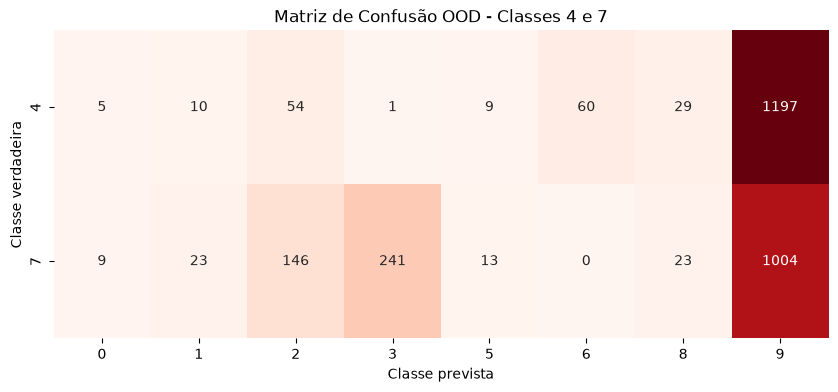

In [39]:
# Exibe a matriz de confusão OOD em formato de heatmap.

plt.figure(figsize=(10, 4))

sns.heatmap(
    matriz_ood,
    annot=True,
    fmt='d',
    cmap='Reds',
    cbar=False
)

plt.title('Matriz de Confusão OOD - Classes 4 e 7')
plt.xlabel('Classe prevista')
plt.ylabel('Classe verdadeira')

plt.show()

### Análise do teste OOD


O modelo foi treinado sem exemplos dos dígitos 4 e 7 e, posteriormente, recebeu apenas imagens dessas duas classes.

Como essas classes não fazem parte das opções aprendidas pelo modelo, ele não consegue prever os rótulos 4 e 7. Ao utilizar predict, atribui a cada imagem uma das classes conhecidas, sem uma opção de rejeitar a entrada como desconhecida.

A associação mais frequente foi com o dígito 9. O dígito 4 foi classificado como 9 em 1.197 casos, enquanto o dígito 7 foi classificado como 9 em 1.004 casos. Também ocorreram outras associações, principalmente do dígito 7 com as classes 3 e 2.

Esses resultados mostram uma limitação do classificador: ele produz uma resposta mesmo quando a classe correta não está entre as classes aprendidas.

Esse comportamento permite discutir o risco de "falsa certeza" (overconfidence), que ocorre quando um modelo apresenta confiança elevada em uma previsão incorreta. Entretanto, neste teste foram analisados apenas os rótulos previstos e suas contagens. Portanto, os resultados não comprovam que o modelo apresentou confiança elevada.

Para investigar esse aspecto, seria necessário analisar também as probabilidades atribuídas às previsões incorretas. Mesmo assim, uma probabilidade alta produzida pelo modelo não garante que a resposta esteja correta, principalmente em dados fora da distribuição de treinamento.

## Fase 5.3 — Inferência com Imagem Manuscrita Própria

Nesta etapa, utilizaremos uma imagem própria de um dígito manuscrito.

O pré-processamento incluirá:

- conversão para escala de cinza;
- inversão das cores, se necessário;
- centralização do dígito e redimensionamento para 28 × 28 pixels;
- normalização dos pixels entre 0 e 1;
- transformação da imagem em um vetor com 784 características.

Depois, utilizaremos o melhor modelo para prever o dígito e exibiremos a imagem processada ao lado do gráfico de probabilidades.

### Carregamento da imagem

Vamos carregar a foto do dígito 3 e exibi-la para conferir o arquivo utilizado.

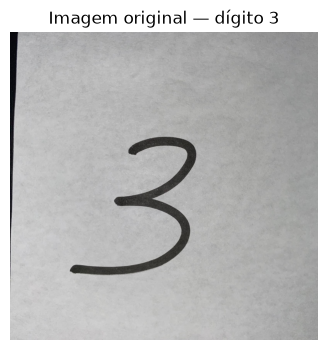

In [40]:
# Indica o arquivo da foto, a partir da pasta notebooks.
caminho_imagem = Path('../images/imagem_thi_.jpeg')

# Registra o dígito verdadeiro apenas para comparar com a previsão.
digito_real = 3

# Abre a imagem.
imagem_original = Image.open(caminho_imagem)

# Exibe a foto.
plt.figure(figsize=(4, 4))
plt.imshow(imagem_original)
plt.title(f'Imagem original — dígito {digito_real}')
plt.axis('off')
plt.show()

### Conversão para cinza e inversão das cores

Vamos converter a foto para escala de cinza e inverter suas cores, deixando o traço do dígito claro sobre um fundo escuro, como no MNIST.

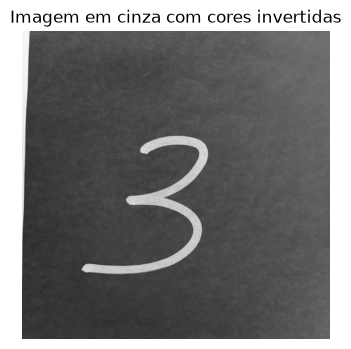

In [41]:
# Converte a foto para escala de cinza.
imagem_cinza = imagem_original.convert('L')

# Inverte as cores, pois esta foto tem papel claro e traço escuro.
imagem_invertida = ImageOps.invert(imagem_cinza)

# Exibe o resultado.
plt.figure(figsize=(4, 4))
plt.imshow(imagem_invertida, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem em cinza com cores invertidas')
plt.axis('off')
plt.show()

### Recorte e centralização

Vamos selecionar a região do dígito com um retângulo de recorte (bounding box), preservar suas proporções e centralizá-lo em uma imagem de 28 × 28 pixels. As coordenadas do recorte são específicas desta foto.

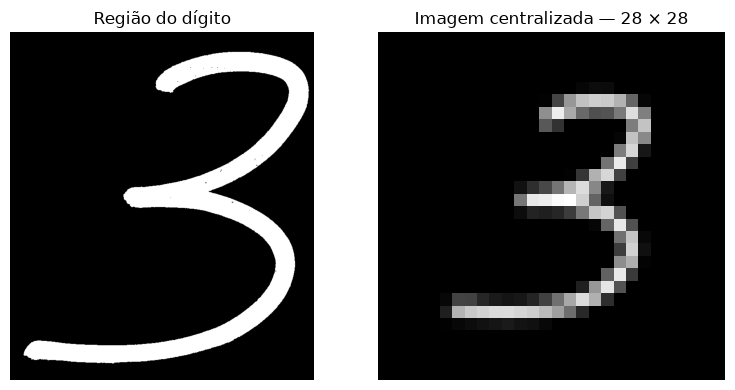

In [42]:
# Define o retângulo que contém o número nesta foto de 1600 x 1600.
# Ordem: esquerda, topo, direita e base.
caixa_digito = (280, 500, 980, 1300)

# Recorta a região do número na imagem com as cores invertidas.
imagem_digito = imagem_invertida.crop(caixa_digito)

# Converte o recorte em uma matriz de pixels.
pixels_digito = np.array(imagem_digito)

# Separa o traço claro do fundo mais escuro.
# O limite 150 é um valor inicial para conferir nesta foto invertida.
pixels_digito = np.where(pixels_digito > 150, 255, 0).astype(np.uint8)

# Converte a matriz novamente em uma imagem.
imagem_digito = Image.fromarray(pixels_digito)

# Reduz o recorte mantendo suas proporções.
# O limite de 20 x 20 deixa espaço para margens na imagem final.
imagem_reduzida = imagem_digito.copy()
imagem_reduzida.thumbnail((20, 20))

# Cria uma imagem preta de 28 x 28 pixels.
imagem_28x28 = Image.new('L', (28, 28), color=0)

# Calcula a posição para centralizar o recorte.
posicao_x = (28 - imagem_reduzida.width) // 2
posicao_y = (28 - imagem_reduzida.height) // 2

# Coloca o recorte no centro da imagem final.
imagem_28x28.paste(imagem_reduzida, (posicao_x, posicao_y))

# Exibe o recorte e a imagem final para conferência.
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(imagem_digito, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Região do dígito')
axes[0].axis('off')

axes[1].imshow(
    imagem_28x28,
    cmap='gray',
    vmin=0,
    vmax=255,
    interpolation='nearest'
)
axes[1].set_title('Imagem centralizada — 28 × 28')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Aplicamos também um limite de intensidade para separar o traço do fundo do papel antes do redimensionamento.

### Normalização e preparação da entrada

Vamos normalizar os pixels para o intervalo de 0 a 1 e transformar a matriz 28 × 28 em uma entrada com 784 características.

In [43]:
# Converte a imagem em uma matriz de números decimais.
imagem_array = np.array(imagem_28x28, dtype=np.float32)

# Normaliza os pixels para o intervalo entre 0 e 1.
imagem_normalizada = imagem_array / 255.0

# Organiza os pixels em uma linha com 784 características.
# Esse é o formato de entrada esperado pelo modelo.
imagem_vetor = imagem_normalizada.reshape(1, 784)

# Confere as dimensões e a faixa dos valores.
print('Formato da imagem:', imagem_normalizada.shape)
print('Formato da entrada do modelo:', imagem_vetor.shape)
print('Menor valor:', imagem_normalizada.min())
print('Maior valor:', imagem_normalizada.max())

Formato da imagem: (28, 28)
Formato da entrada do modelo: (1, 784)
Menor valor: 0.0
Maior valor: 1.0


### Predição e probabilidades

Utilizaremos o MLP completo, que apresentou o melhor desempenho, para prever o dígito. Exibiremos a imagem processada ao lado das probabilidades atribuídas às classes de 0 a 9.

Dígito real: 3
Dígito previsto: 3


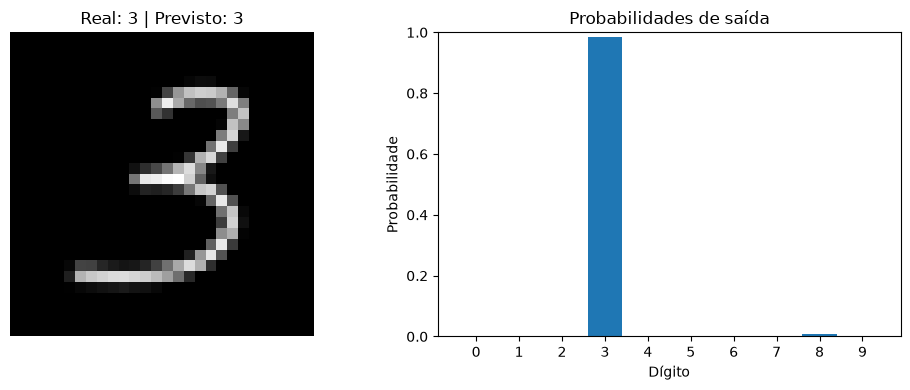

In [46]:
# Utiliza o modelo completo da Fase 4 para prever o dígito.
# O [0] seleciona o resultado da única imagem enviada.
digito_previsto = modelo_final_mlp.predict(imagem_vetor)[0]

# Obtém as probabilidades das dez classes para essa imagem.
probabilidades = modelo_final_mlp.predict_proba(imagem_vetor)[0]

# Mostra o dígito verdadeiro e a previsão.
print('Dígito real:', digito_real)
print('Dígito previsto:', digito_previsto)

# Cria dois espaços para os gráficos, lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Exibe a imagem que foi enviada ao modelo.
axes[0].imshow(
    imagem_normalizada,
    cmap='gray',
    vmin=0,
    vmax=1,
    interpolation='nearest'
)
axes[0].set_title(f'Real: {digito_real} | Previsto: {digito_previsto}')
axes[0].axis('off')

# Exibe as probabilidades na mesma ordem das classes do modelo.
axes[1].bar(
    modelo_final_mlp.classes_,
    probabilidades
)
axes[1].set_title('Probabilidades de saída')
axes[1].set_xlabel('Dígito')
axes[1].set_ylabel('Probabilidade')
axes[1].set_xticks(modelo_final_mlp.classes_)
axes[1].set_ylim(0, 1)

# Ajusta o espaço entre os gráficos e exibe a figura.
plt.tight_layout()
plt.show()

### Análise da imagem própria

O MLP classificou corretamente a imagem própria como dígito 3, atribuindo a maior probabilidade a essa classe.

A foto foi convertida para escala de cinza, teve suas cores invertidas e recebeu um recorte manual da região do número. Aplicamos um limite de intensidade para separar o traço do papel, centralizamos o recorte em 28 × 28 pixels e normalizamos os valores entre 0 e 1.

O resultado demonstra que o modelo reconheceu esta imagem após o pré-processamento. Entretanto, um único acerto não garante o mesmo desempenho em outras fotos. As coordenadas do recorte e o limite de intensidade foram definidos para esta imagem e podem precisar de ajustes em outras entradas.